# Cellpose segmentation of cells and nuclei

This is a Python notebook to run **Cellpose**, a machine learning-based segmentation software. Follow the instructions and run each code cell successively.

## 0. Image upload and notebook setup
a. Start by uploading the images to segment to a Google Drive folder. Make sure this folder contains no other files beside the images.

*Note: Cellpose works with both brightfield and fluorescence microscopy images, and may take as input single-channel, multi-channel or RGB images.*

b. Navigate to **Runtime > Change runtime type** and set the runtime type to T4 GPU.

In [ ]:
#@title Link Google Colaboratory to Drive account to access files

from google.colab import drive
drive.mount('/content/drive')

# Acá abajo le damos acceso a nuestra unidad de Drive
file_root = '/content/drive/My Drive/'

Mounted at /content/drive


In [ ]:
#@title Install Cellpose
%%capture
!pip install cellpose

**Important:** Restart runtime after running previous cell.

In [ ]:
#@title Import libraries

import numpy as np
import scipy as sp
import skimage as ski
import os
import cellpose as cp
from matplotlib import pyplot as plt
from skimage import data, color
from skimage.transform import rescale, resize, downscale_local_mean
from cellpose import models, io
from cellpose.io import imread

## 1. Load images

Type in the path to the folder with the images to segment.

In [ ]:
path = "/content/drive/MyDrive/MIE/Cellpose/" # @param {"type":"string"}
path1 = path + "*"

imgs = ski.io.imread_collection(path1) # Load image list
file_list = imgs.files

In [ ]:
#@title Optional: check file list to see if images were loaded correctly.
file_list

['/content/drive/MyDrive/Cellpose/Fotos prueba cellpose/C1-JPArsv13.tif',
 '/content/drive/MyDrive/Cellpose/Fotos prueba cellpose/C1-JPBasalv1.tif',
 '/content/drive/MyDrive/Cellpose/Fotos prueba cellpose/C1-LFArsv11.tif']

## 2. Test model parameters


Select an image to preview and test the segmentation model. (Type in image number)

In [ ]:
img_ID = 0 # @param {"type":"integer"}

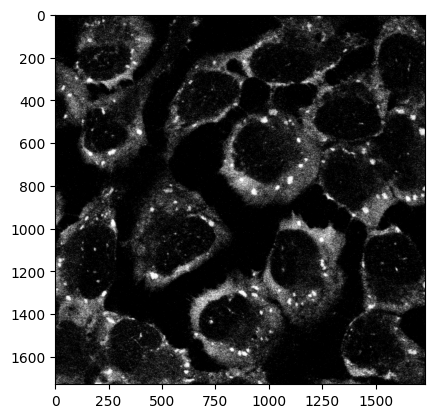

In [ ]:
#@title Preview image
plt.imshow(imgs[img_ID], cmap='gray')
plt.show()

Set model parameters:
- model_type: use "cyto3" for segmentation of cells, "nuclei" for segmentation of nuclei.
- object_diameter: approximate diameter of cells (or nuclei), in pixels, as judged by the scale in image preview above. If set to 0, Cellpose estimates the diameter (not recommended).
- flow_threshold: increase this threshold if Cellpose is not returning as many ROIs as expected; decrease this threshold if Cellpose is returning too many ill-shaped ROIs. Default value: 0.4.
- cellprob_threshold: decrease this threshold if Cellpose is not returning as many ROIs as expected; increase this threshold if Cellpose is returning too many ROIs, particularly from dim areas.

(From https://cellpose.readthedocs.io/en/latest/settings.html)

In [ ]:
model_type = "cyto3" # @param {"type":"string"}

object_diameter = 400 # @param {"type":"integer"}

flow_thr = 0.4 # @param {"type":"number"}

cellprob_thr = 0.0 # @param {"type":"number"}

[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-21 18:21:05,629 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-07-21 18:21:05,630 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-21 18:21:05,632 [models WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-07-21 18:21:05,967 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-21 18:21:05,969 [core INFO] >>>> using GPU (CUDA)
2026-07-21 18:21:09,134 [models INFO] >>>> loading model /root/.cellpose/models/cpsam_v2


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


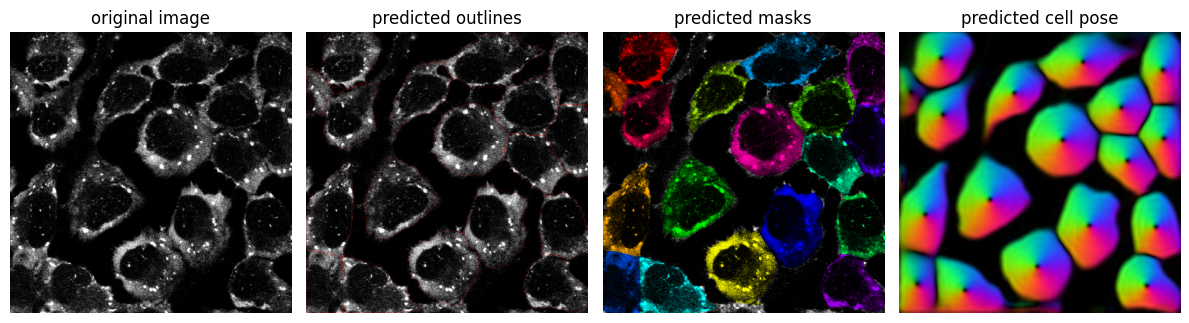

In [ ]:
#@title Run single image test segmentation
## Single image segmentation
io.logger_setup()
model = models.CellposeModel(gpu=True, model_type=model_type)

masks, flows, styles = model.eval(imgs[img_ID],
                                  diameter = object_diameter)

## Show segmentation result
from cellpose import plot
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, imgs[img_ID], masks, flows[0])
plt.tight_layout()
plt.show()

Tweak the model parameters in the input fields above (especially object_diameter) until satisfied with the segmentation results.

## 3. Batch process images and export segmentation results

In [ ]:
#@title Run batch segmentation on whole image set

io.logger_setup()
masks, flows, styles = model.eval(list(imgs),
                                  diameter = object_diameter)


[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-21 18:21:29,256 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-07-21 18:21:29,257 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-21 18:22:09,374 [utils INFO] 100%|##########| 3/3 [00:40<00:00, 13.37s/it]


In [ ]:
#@title Save segmentations as ROI sets
from pathlib import Path
for i in range(len(masks)):
    fileName = Path(file_list[i]).stem
    io.save_rois(masks[i], path + fileName)

import glob
ROIsets = glob.glob(path + "*.zip") # Get list of .zip files in folder
for i in range(len(ROIsets)):
  newname = ROIsets[i].replace("_rois", "") # Remove "_rois" suffix from file name
  os.rename(ROIsets[i], newname)

The generated ROI sets are saved in the same folder that contains the images; each ROI set is a .zip file that can be directly opened in FIJI.